In [3]:
print("Loading packages")
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

#notes
#consider multiple edges/self loops

Loading packages


In [13]:
stages = [3,4,5,6,7,8,9,10,11,12,13]
stage = 12
n=1

#spatial resolution: number of pixels per micron
#MAKE SURE this matches the ratio used in the skeleton.ijm macro!
pix_micron_ratio = 0.25

microns_per_pixel = 1/pix_micron_ratio

base=2 #intercept term
dist_propn=0.08 #multiplier term

path = f"data/skeleton/test_data/"

image = cv2.imread(f'{path}n{n}_hh{stage}_skeleton.jpg')
dists = cv2.imread(f"{path}n{n}_hh{stage}_distmap.jpg") 


threshold=0.85
base=2
dist_propn=0.08

height = len(image)
width = len(image[0])
print(f"Dimensions in pixels {width}x{height}")
#print(f"There are {microns_per_pixel} microns per pixel")
print(f"Dimensions in microns {width*microns_per_pixel}x{height*microns_per_pixel}")

#set up node and edge matrices
nodes,adj = nodes_edges_from_image(image,dists,threshold,microns_per_pixel)
print(f"Unmerged length:{len(nodes)}")


#apply merging on nearby nodes
nodes2,adj2 = merge_nearby_nodes(nodes,adj,dist_propn,base,microns_per_pixel)
print(f"Merged length:{len(nodes2)}")


Dimensions in pixels 1864x2958
Dimensions in microns 7456.0x11832.0
Unmerged length:814
Merged length:555


In [ ]:
def image_plot(image,size,x_min,y_min):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray)
    ax.axis('off') 

    x_max,y_max = x_min+size[0],y_min+size[1]

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

In [ ]:
def nodes_plot(image,nodes,adj,node_alpha=0.4,edge_alpha=1,im_alpha=1,edge_weights=False,node_weights=False):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray,alpha=im_alpha)
    ax.axis('off') 

    size = [100,80]
    x_min = 1170
    y_min = 2220
    x_max,y_max = x_min+size,y_min+80



    #calculate nodes and edges
    patches = []
    for i in nodes.index:
        x,y,weight,type = nodes[["x","y","weight","type"]].loc[i]
        if x_min<=x<=x_max and y_min<=y<=y_max: #only plot the valid region
            if type == "junction": #colourings
                circle = Circle((x, y), 1+weight/20,color="#e2342c")
            else: 
                circle = Circle((x, y), 1+weight/20,color="#f2ad00")
            patches.append(circle)

            #text labelling
            if node_weights and int(weight)!=76 and int(weight)!=70 and int(weight)!=12: #hacky line to remove overlapping numbers
                ax.text(x, y, str(int(weight)), ha='center', va='center', fontsize=20, color='white',font="arial",weight="bold")
            
            
    p = PatchCollection(patches, alpha=node_alpha,match_original=True)
    ax.add_collection(p)


    #code for edges
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                if x_min<=x1<=x_max and y_min<=y1<=y_max:
                    ax.plot([x1,x2],[y1,y2],alpha=edge_alpha,linewidth=5)

                    #text labelling
                    av_x,av_y = (x1+x2)/2, (y1+y2)/2
                    if edge_weights and int(dist)!=4 and int(dist)!=244:
                        ax.text(av_x, av_y, str(int(dist)), ha='left', va='bottom', fontsize=20, color='white' ,font="arial",weight="bold")


    

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

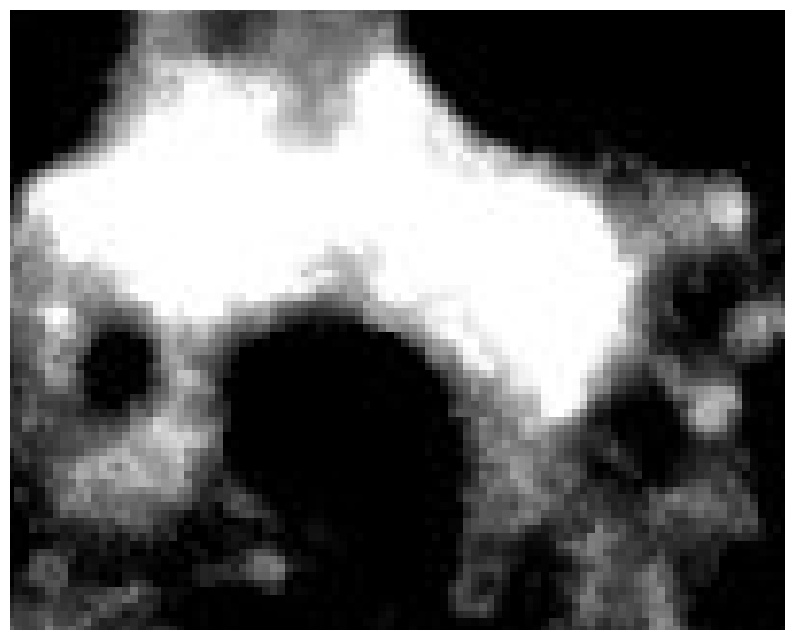

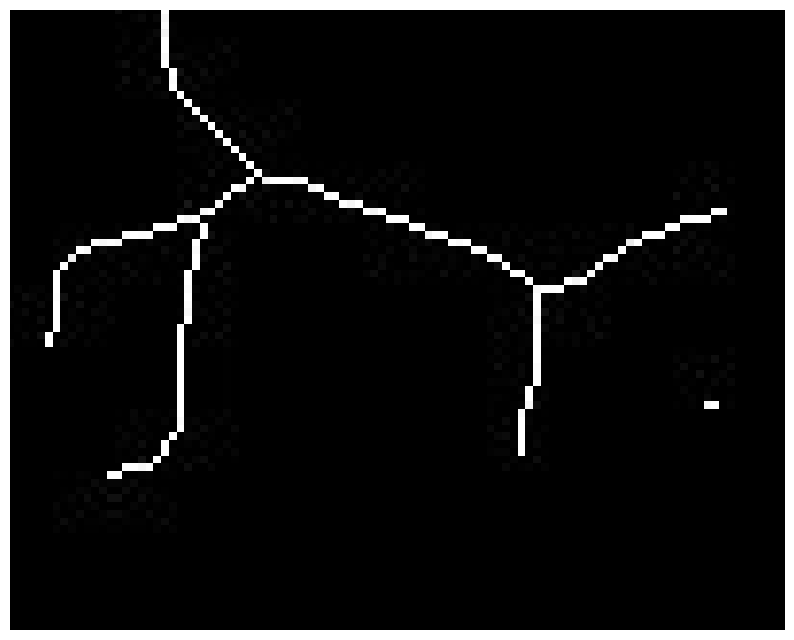

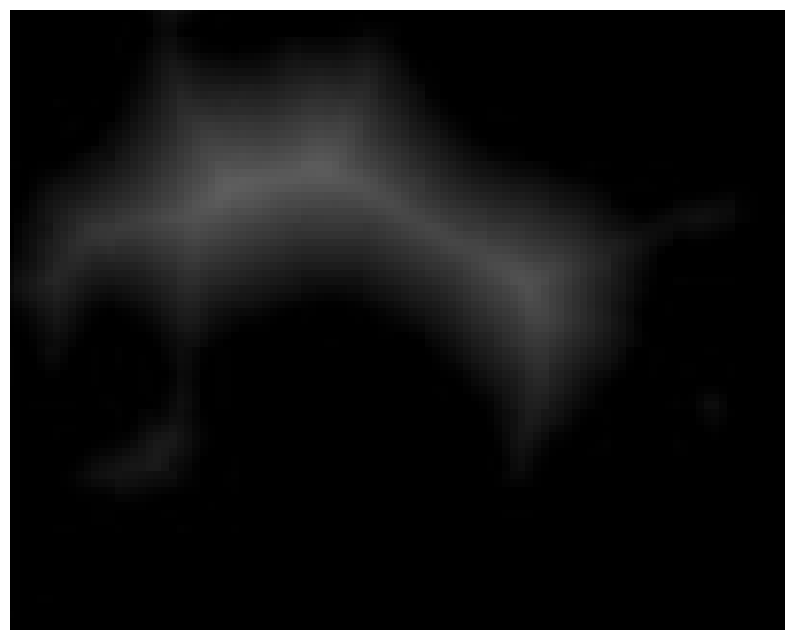

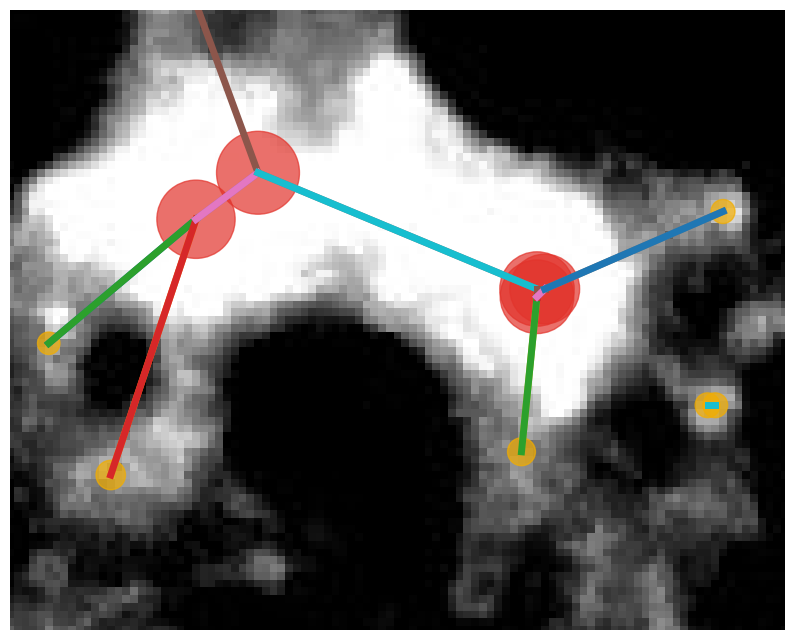

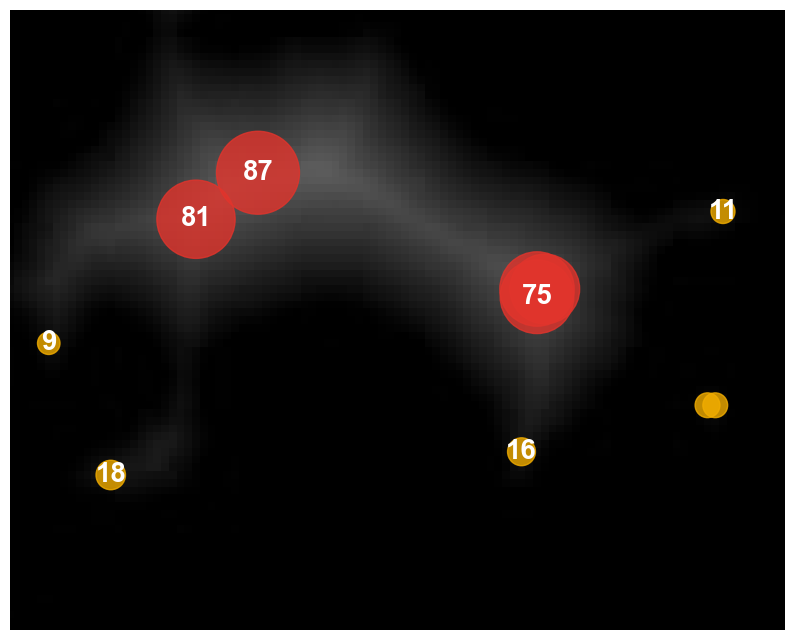

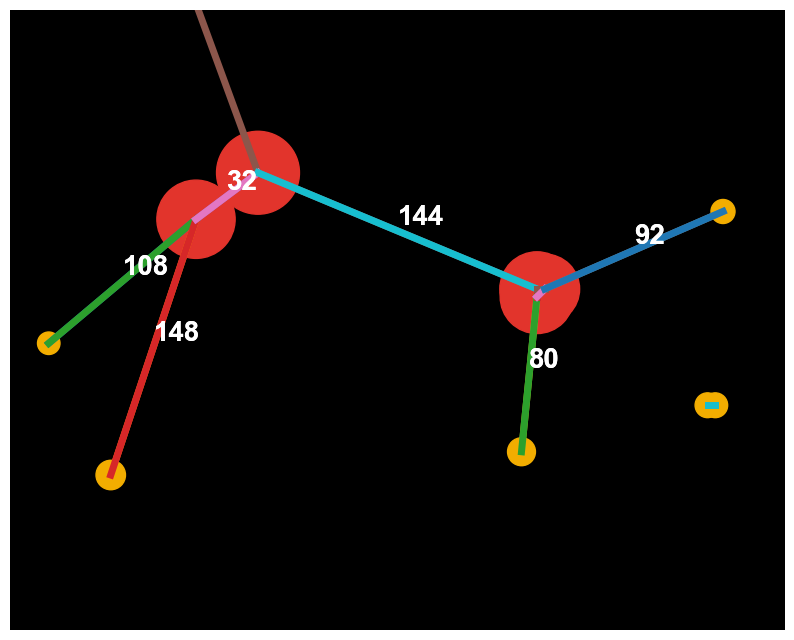

In [ ]:
original = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
skele = cv2.imread(f'{path}n{n}_hh{stage}_skeleton.jpg')
dists = cv2.imread(f"{path}n{n}_hh{stage}_distmap.jpg") 
black = cv2.imread(f"{path}black.jpg") 


size = 100
x_min = 1170
y_min = 2220

image_plot(original,size,x_min,y_min)
image_plot(skele,size,x_min,y_min)
image_plot(dists,size,x_min,y_min)


#nodes_plot(skele,nodes,adj)
nodes_plot(original,nodes,adj,node_alpha=0.7)

nodes_plot(dists,nodes,adj,edge_alpha=0,node_alpha=0.8,node_weights=True)
nodes_plot(black,nodes,adj,node_alpha=1,edge_weights=True)

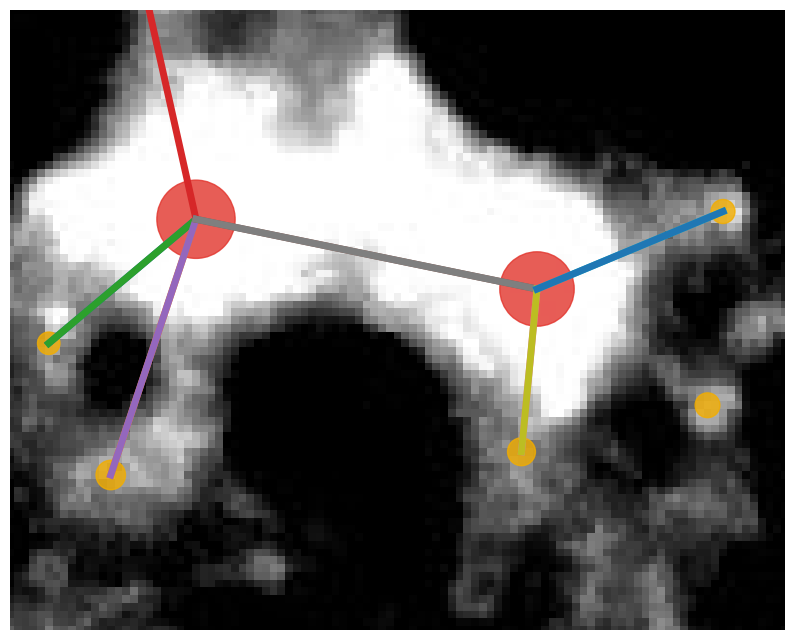

In [ ]:
#merged

#nodes_plot(skele,nodes2,adj2)
nodes_plot(original,nodes2,adj2,node_alpha=0.8)

In [46]:
import tifffile as tiff

stages = [3,4,5,6,7,8,9,10,11,12,13]
stage = 12
n=1

#spatial resolution: number of pixels per micron
#MAKE SURE this matches the ratio used in the skeleton.ijm macro!
pix_micron_ratio = 0.25

microns_per_pixel = 1/pix_micron_ratio

base=2 #intercept term
dist_propn=0.08 #multiplier term

path = f"data/skeleton/test_data/hh6/"

image = tiff.imread(f'{path}skele.tif')
dists = tiff.imread(f"{path}distmap.tif") 


threshold=0.85
base=2
dist_propn=0.08

height = len(image)
width = len(image[0])
print(f"Dimensions in pixels {width}x{height}")
#print(f"There are {microns_per_pixel} microns per pixel")
print(f"Dimensions in microns {width*microns_per_pixel}x{height*microns_per_pixel}")

#set up node and edge matrices
nodes,adj = nodes_edges_from_image(image,dists,threshold,microns_per_pixel)
print(f"Unmerged length:{len(nodes)}")


#apply merging on nearby nodes
nodes2,adj2 = merge_nearby_nodes(nodes,adj,dist_propn,base,microns_per_pixel)
print(f"Merged length:{len(nodes2)}")

Dimensions in pixels 138x142
Dimensions in microns 552.0x568.0
No path found
[(np.int64(118), np.int64(23)), (118, 22), (117, 21), (117, 20), (117, 19), (117, 18), (117, 17), (117, 16), (117, 15), (117, 14), (117, 13), (117, 12), (117, 11), (117, 10), (117, 9), (117, 8), (117, 7), (118, 6), (118, 5), (118, 4), (117, 3), (117, 2), (117, 1)]
No path found
[(np.int64(135), np.int64(41)), (136, 41)]
Unmerged length:22
Merged length:19


In [53]:
def nodes_plot(image,nodes,adj,node_alpha=0.4,edge_alpha=1,im_alpha=1,edge_weights=False,node_weights=False):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray,alpha=im_alpha)
    ax.axis('off') 


    #calculate nodes and edges
    patches = []
    for i in nodes.index:
        x,y,weight,type = nodes[["x","y","weight","type"]].loc[i]
        if type == "junction": #colourings
            circle = Circle((x, y), 1+weight/3,color="#e2342c")
        else: 
            circle = Circle((x, y), 1+weight/3,color="#f2ad00")
        patches.append(circle)

        #text labelling
        if node_weights and int(weight)!=76 and int(weight)!=70 and int(weight)!=12: #hacky line to remove overlapping numbers
            ax.text(x, y, str(int(weight)), ha='center', va='center', fontsize=20, color='white',font="arial",weight="bold")
            
            
    p = PatchCollection(patches, alpha=node_alpha,match_original=True)
    ax.add_collection(p)


    #code for edges
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                ax.plot([x1,x2],[y1,y2],alpha=edge_alpha,linewidth=5,color="tab:blue")

                #text labelling
                av_x,av_y = (x1+x2)/2, (y1+y2)/2
                if edge_weights and int(dist)!=4 and int(dist)!=244:
                    ax.text(av_x, av_y, str(int(dist)), ha='left', va='bottom', fontsize=20, color='white' ,font="arial",weight="bold")


    


    plt.show()

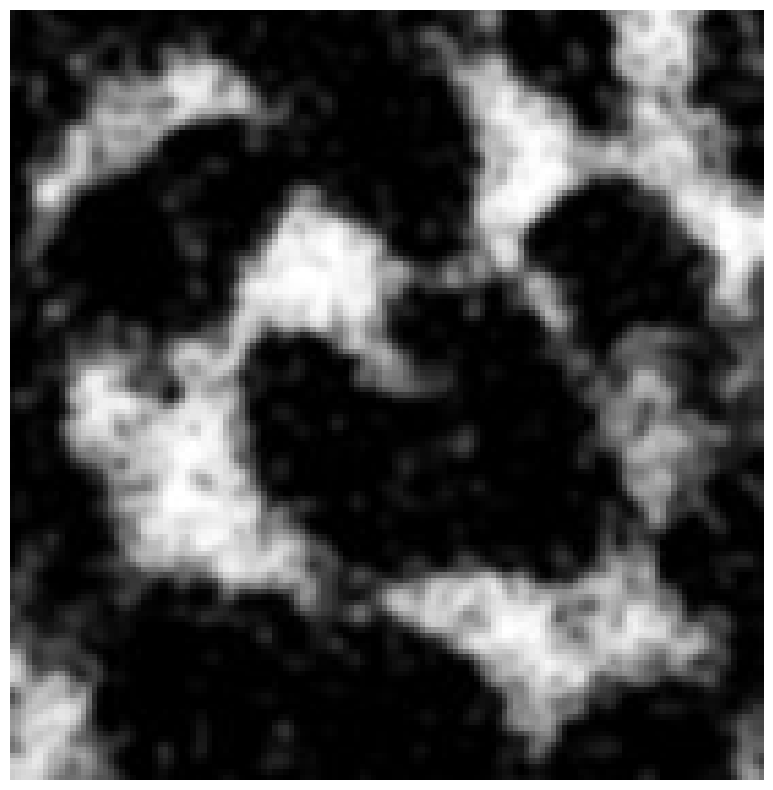

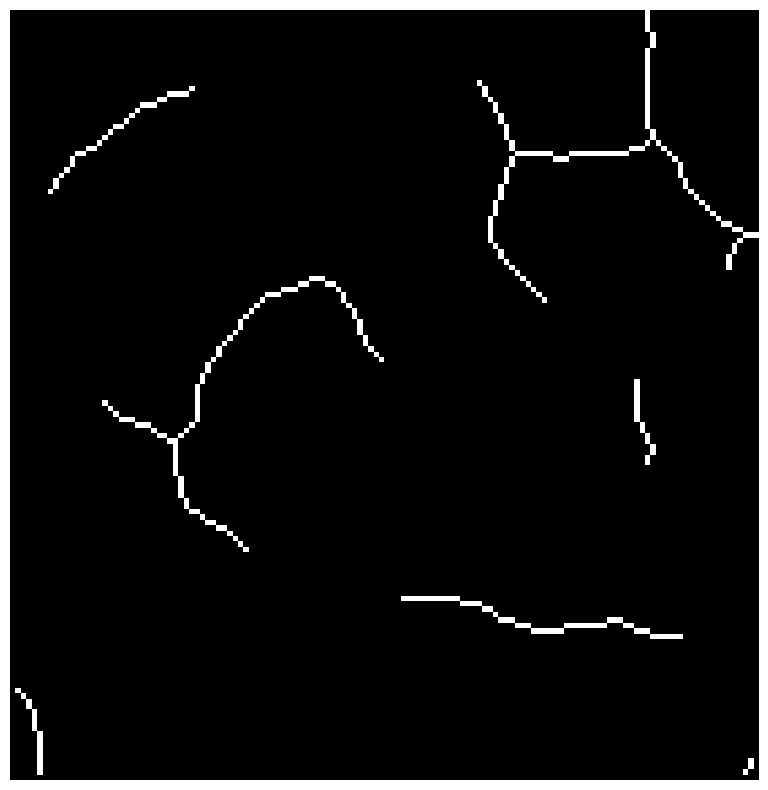

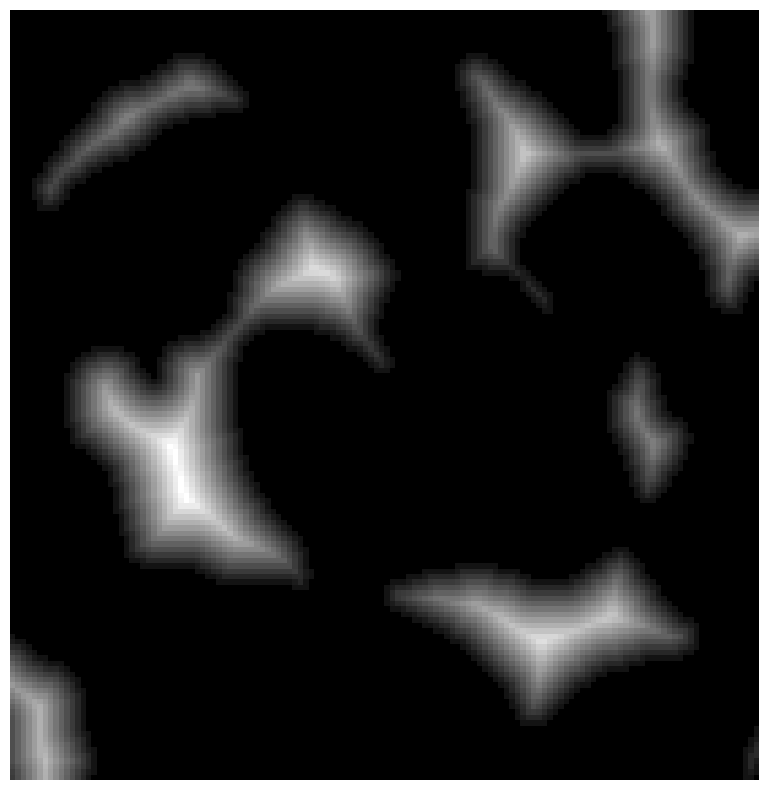

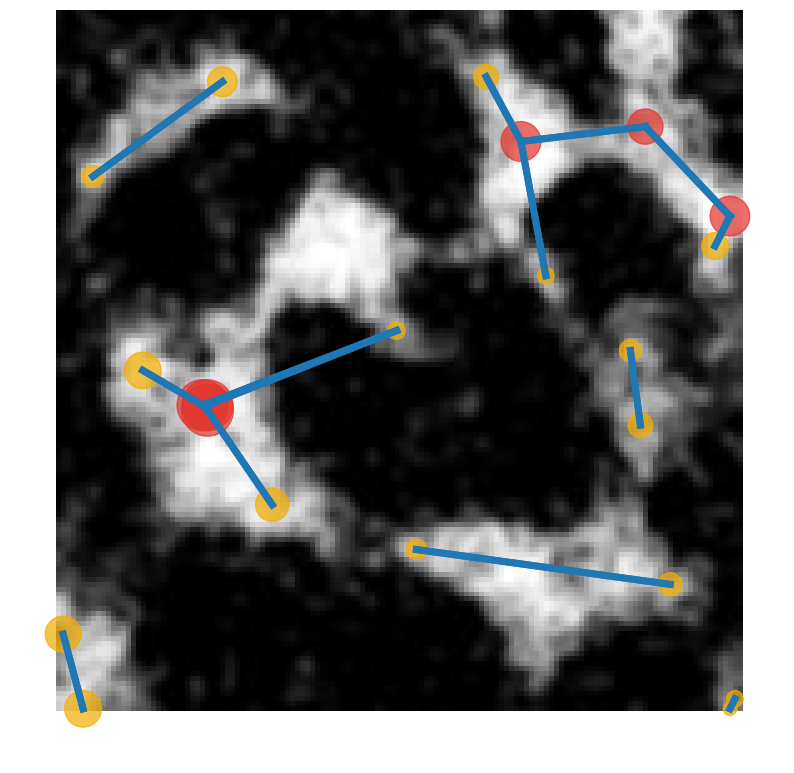

      0     1      2     3      4      5     6      7     8      9   ...  \
0    NaN  60.0    NaN   NaN    NaN    NaN   NaN    NaN   NaN    NaN  ...   
1   60.0   NaN    NaN   NaN    NaN    NaN   NaN    NaN   NaN    NaN  ...   
2    NaN   NaN    NaN   NaN    NaN    NaN   NaN  112.0   NaN    NaN  ...   
3    NaN   NaN    NaN   NaN   48.0    NaN   NaN    NaN   NaN    NaN  ...   
4    NaN   NaN    NaN  48.0    NaN    4.0   4.0    NaN   NaN  212.0  ...   
5    NaN   NaN    NaN   NaN    4.0    NaN   4.0    NaN   NaN  212.0  ...   
6    NaN   NaN    NaN   NaN    4.0    4.0   NaN    NaN  88.0    NaN  ...   
7    NaN   NaN  112.0   NaN    NaN    NaN   NaN    NaN   NaN    NaN  ...   
8    NaN   NaN    NaN   NaN    NaN    NaN  88.0    NaN   NaN    NaN  ...   
9    NaN   NaN    NaN   NaN  212.0  212.0   NaN    NaN   NaN    NaN  ...   
10   NaN   NaN    NaN   NaN    NaN    NaN   NaN    NaN   NaN    NaN  ...   
11   NaN   NaN    NaN   NaN    NaN    NaN   NaN    NaN   NaN    NaN  ...   
12   NaN   N

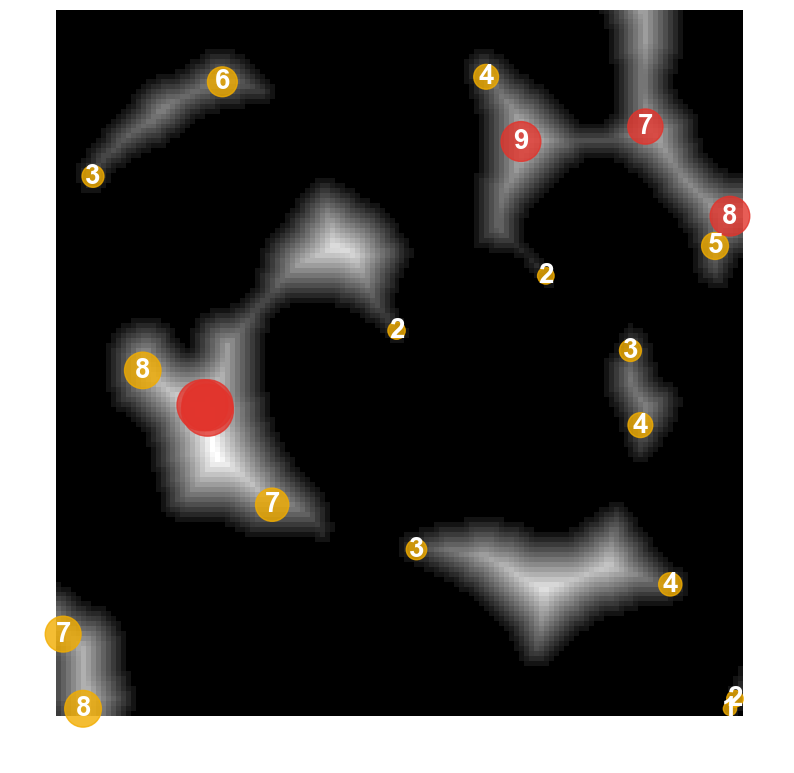

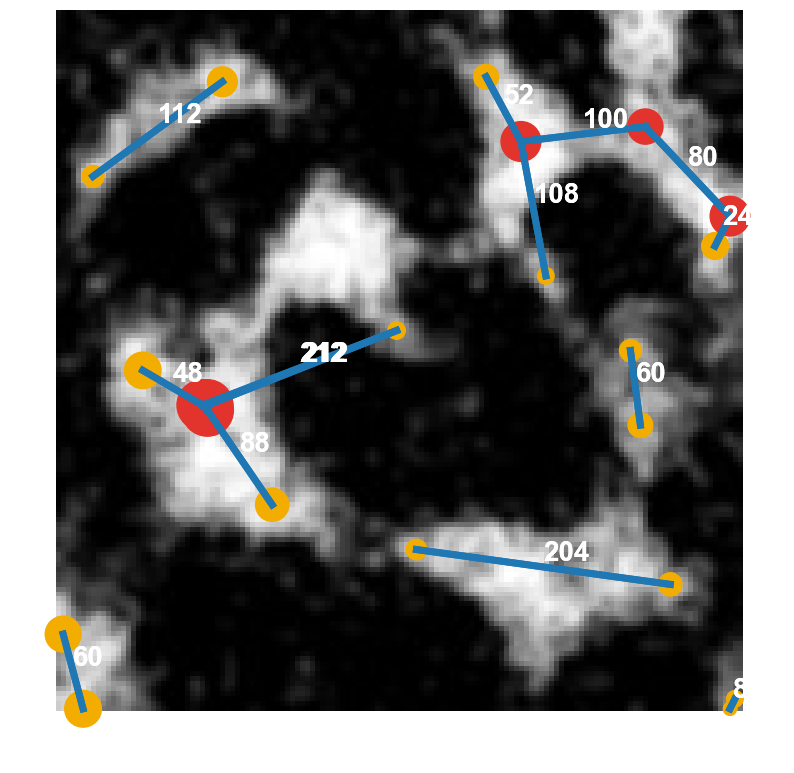

In [ ]:
original = tiff.imread(f'{path}plain.tif')
original = cv2.imread(f"{path}hh6_flattened_blur-1.jpg")
skele = tiff.imread(f'{path}skele.tif')
dists = tiff.imread(f"{path}distmap.tif") 

size=[len(original),len(original[0])]
x_min=0
y_min=0

image_plot(original,size,x_min,y_min)
image_plot(skele,size,x_min,y_min)
image_plot(dists,size,x_min,y_min)


#nodes_plot(skele,nodes,adj)
nodes_plot(original,nodes,adj,node_alpha=0.7)

print(adj)
print(nodes)

nodes_plot(dists,nodes,adj,edge_alpha=0,node_alpha=0.8,node_weights=True)
nodes_plot(original,nodes,adj,node_alpha=1,edge_weights=True)

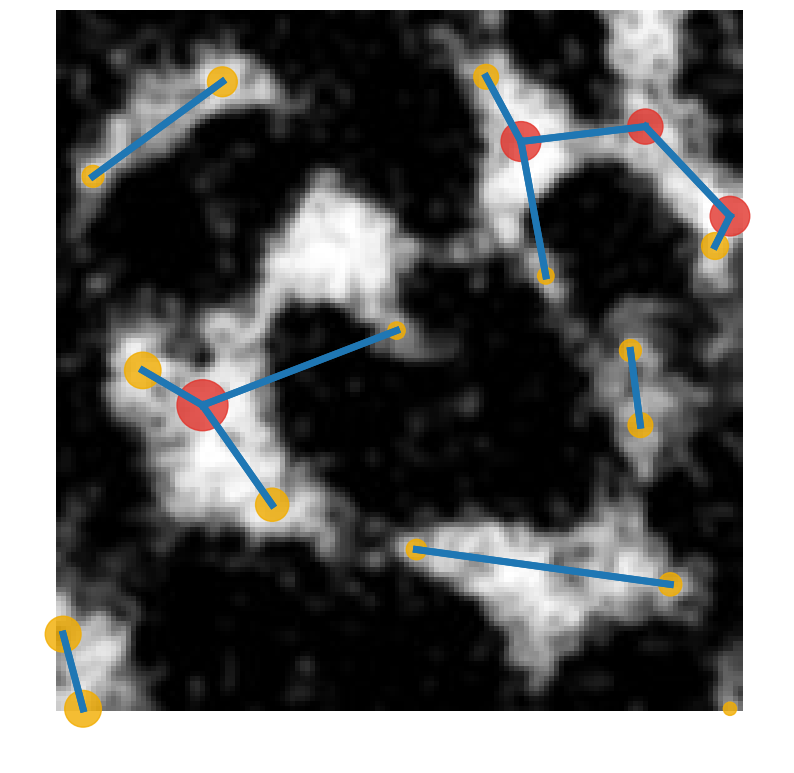

In [55]:
#merged

#nodes_plot(skele,nodes2,adj2)
nodes_plot(original,nodes2,adj2,node_alpha=0.8)

In [34]:
import tifffile as tiff

stages = [3,4,5,6,7,8,9,10,11,12,13]
n=1
stage=10


#spatial resolution: number of pixels per micron
#MAKE SURE this matches the ratio used in the skeleton.ijm macro!
pix_micron_ratio = 0.25

microns_per_pixel = 1/pix_micron_ratio


path = f"data/skeleton/all/"

image = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
dists = tiff.imread(f"{path}n{n}_hh{stage}_distmap.tif") 


threshold=0.85
base=2
dist_propn=0.5

height = len(image)
width = len(image[0])
print(f"Dimensions in pixels {width}x{height}")
#print(f"There are {microns_per_pixel} microns per pixel")
print(f"Dimensions in microns {width*microns_per_pixel}x{height*microns_per_pixel}")

#set up node and edge matrices
nodes,adj = nodes_edges_from_image(image,dists,threshold,microns_per_pixel)
print(f"Unmerged length:{len(nodes)}")


#apply merging on nearby nodes
nodes2,adj2 = merge_nearby_nodes(nodes,adj,dist_propn,base,microns_per_pixel)
print(f"Merged length:{len(nodes2)}")

Dimensions in pixels 1864x2324
Dimensions in microns 7456.0x9296.0
Unmerged length:1026
Merged length:750


In [43]:
def nodes_plot(image,nodes,adj,node_alpha=0.4,edge_alpha=1,im_alpha=1,edge_weights=False,node_weights=False):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray,alpha=im_alpha)
    ax.axis('off') 

    size = 250
    x_min = 1279
    y_min = 1695
    x_max,y_max = x_min+size,y_min+size


    #calculate nodes and edges
    patches = []
    for i in nodes.index:
        x,y,weight,type = nodes[["x","y","weight","type"]].loc[i]
        if x_min<=x<=x_max and y_min<=y<=y_max: #only plot the valid region
            if type == "junction": #colourings
                circle = Circle((x, y), 1+weight/3,color="#e2342c")
            else: 
                circle = Circle((x, y), 1+weight/3,color="#f2ad00")
            patches.append(circle)

            #text labelling
            if node_weights and int(weight)!=76 and int(weight)!=70 and int(weight)!=12: #hacky line to remove overlapping numbers
                ax.text(x, y, str(int(weight)), ha='center', va='center', fontsize=20, color='white',font="arial",weight="bold")
            
            
    p = PatchCollection(patches, alpha=node_alpha,match_original=True)
    ax.add_collection(p)


    #code for edges
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                if x_min<=x1<=x_max and y_min<=y1<=y_max:
                    ax.plot([x1,x2],[y1,y2],alpha=edge_alpha,linewidth=5,color="tab:blue")

                    #text labelling
                    av_x,av_y = (x1+x2)/2, (y1+y2)/2
                    if edge_weights and int(dist)!=4 and int(dist)!=244:
                        ax.text(av_x, av_y, str(int(dist)), ha='left', va='bottom', fontsize=20, color='white' ,font="arial",weight="bold")


    

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

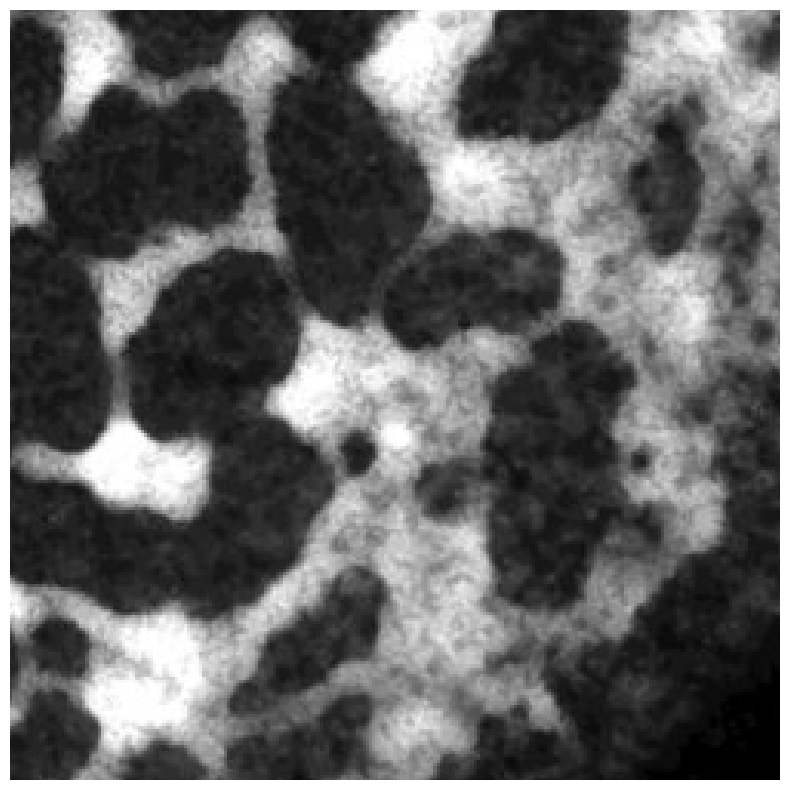

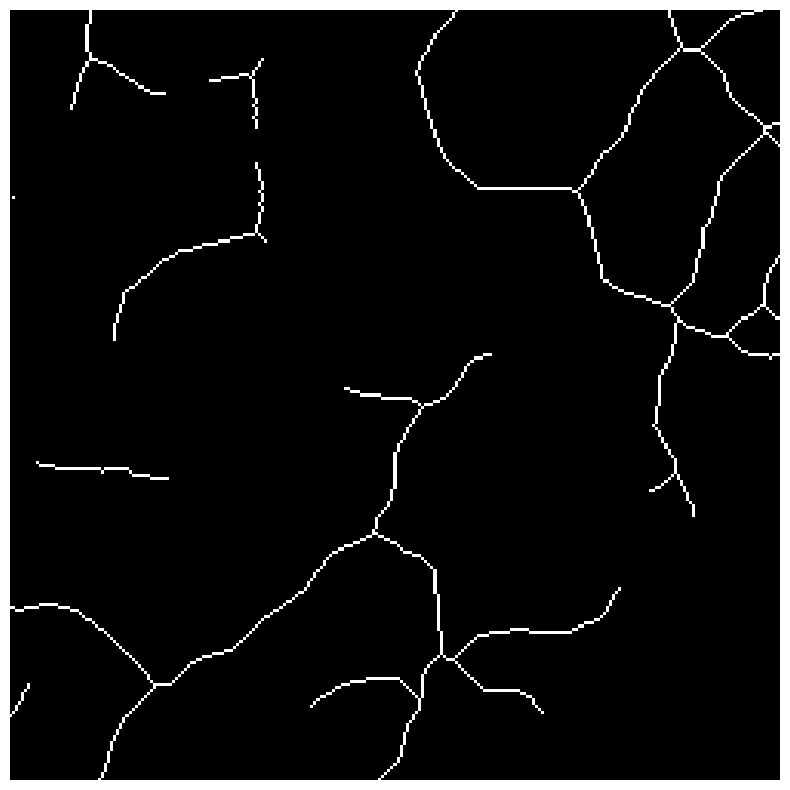

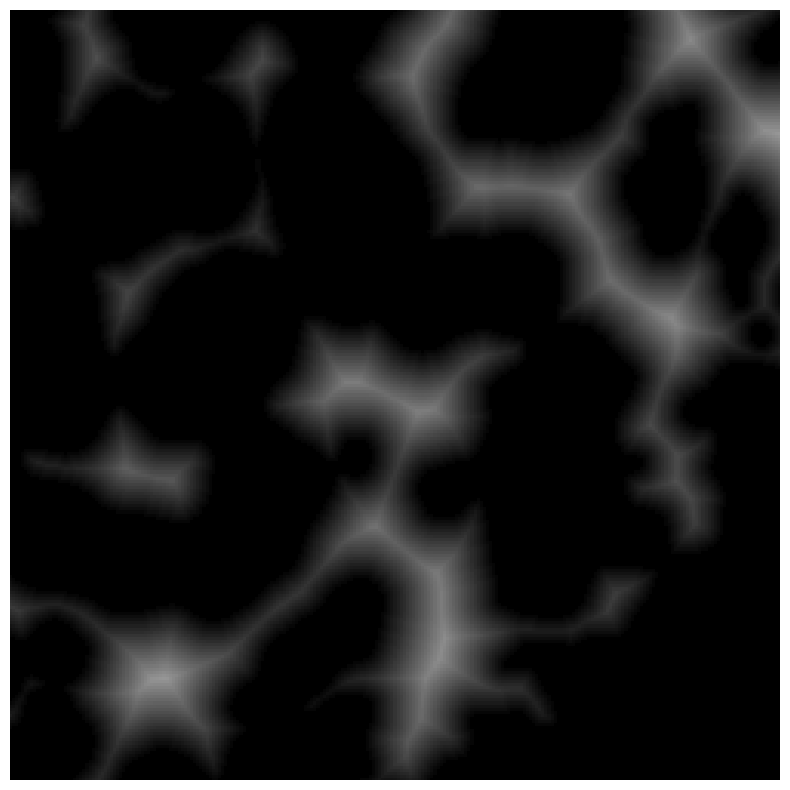

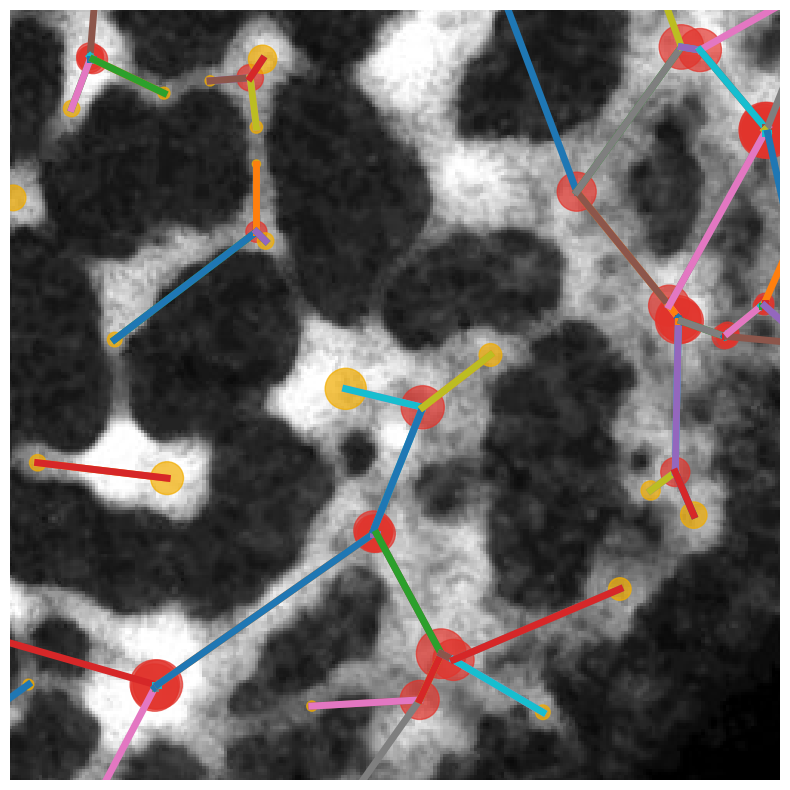

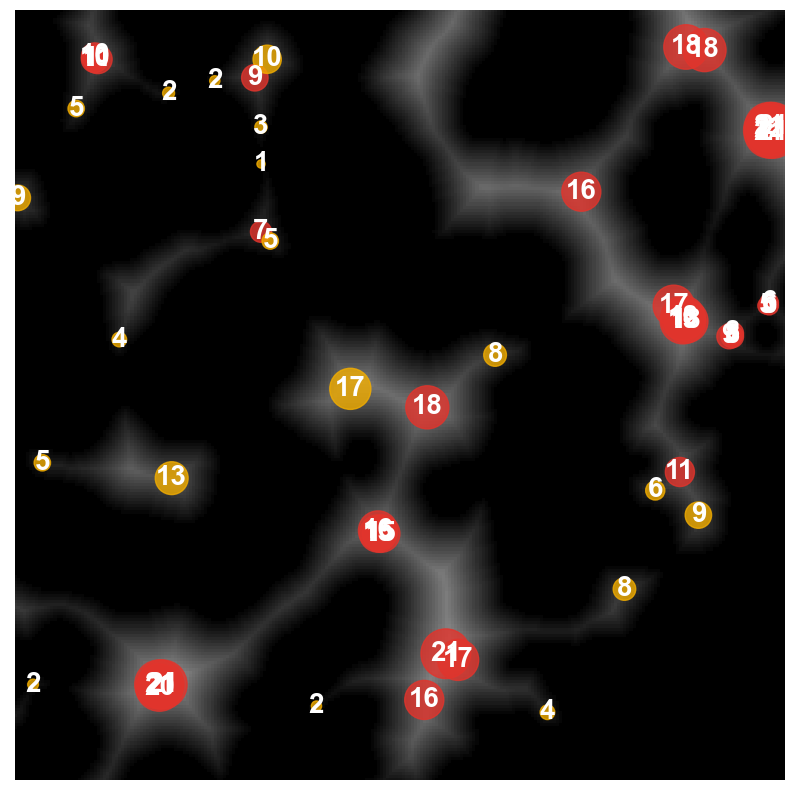

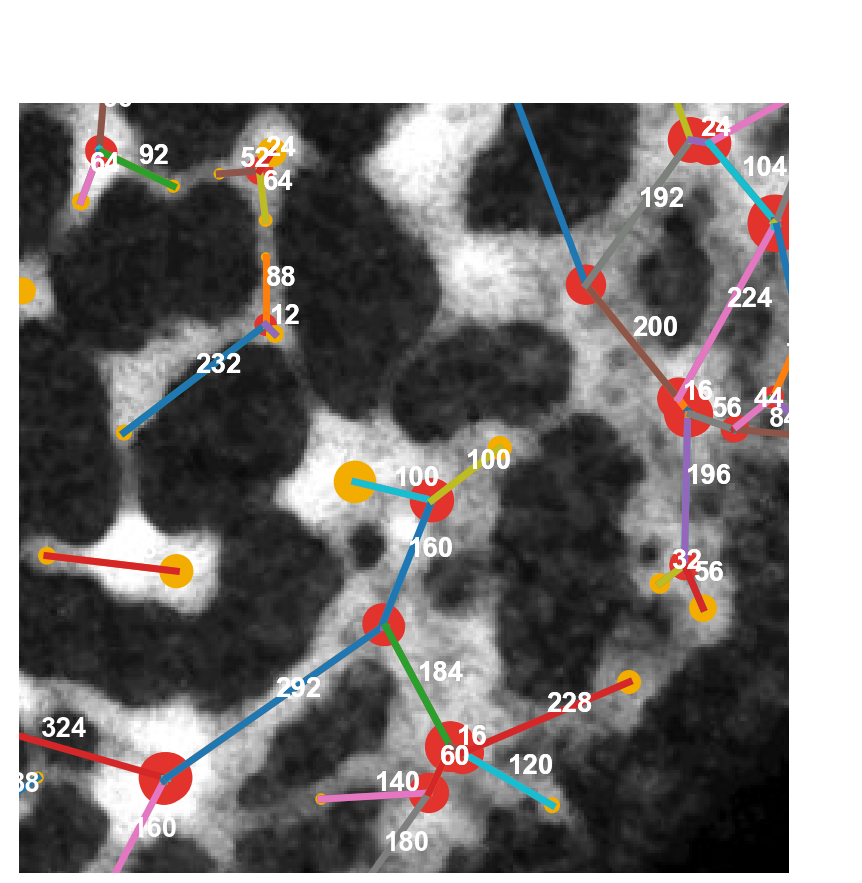

In [ ]:
original = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
original =cv2.imread(f"data/skeleton/test_data/hh10/flattened2_scaled.jpg")
skele = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
dists = tiff.imread(f"{path}n{n}_hh{stage}_distmap.tif") 

size = [250,250]
x_min = 1279
y_min = 1695

image_plot(original,size,x_min,y_min)
image_plot(skele,size,x_min,y_min)
image_plot(dists,size,x_min,y_min)


#nodes_plot(skele,nodes,adj)
nodes_plot(original,nodes,adj,node_alpha=0.7)
nodes_plot(dists,nodes,adj,edge_alpha=0,node_alpha=0.8,node_weights=True)
nodes_plot(original,nodes,adj,node_alpha=1,edge_weights=True)

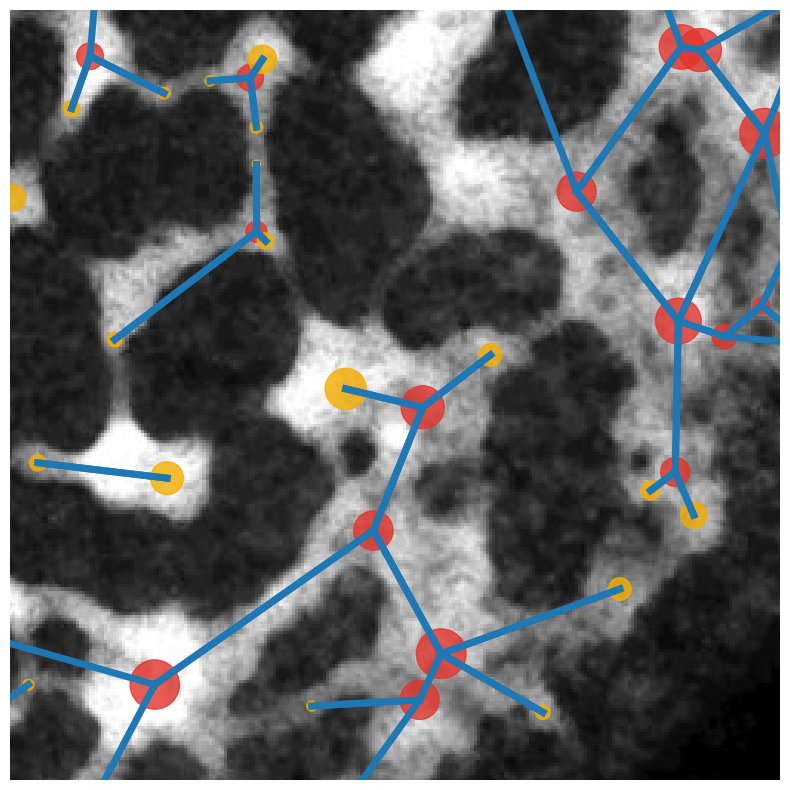

In [44]:
#merged

#nodes_plot(skele,nodes2,adj2)
nodes_plot(original,nodes2,adj2,node_alpha=0.8)